# PD with DAI Scoring Example
This is demo of PD for Driverless AI Python scoring pipeline.

# Virtual Environment and Dependencies
Prepare and activate virtual environment for the demo by running:
```
make test_install_dai_scoring
. .venv/bin/activate
pip install ipykernel
ipython kernel install --user --name=dai-1-5-dev
```
Import dependencies:

In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
from functools import partial
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
from mli.explanation.pd import PD
from mli.explanation.h_statistic import HStatistic

## UCI Credit Card Dataset

The UCI credit card default data contains demographic and payment information about credit card customers in Taiwan in the year 2005. The data set contains 23 input variables:

* `LIMIT_BAL`
   * Amount of given credit (NT dollar)
* `SEX`
   * 1 = male; 2 = female
* `EDUCATION`
   * 1 = graduate school; 2 = university; 3 = high school; 4 = others
* `MARRIAGE`
   * 1 = married; 2 = single; 3 = others
* `AGE`
   * Age in years
* `PAY_1, PAY_2 - PAY_6`
   * History of past payment; PAY_1 = the repayment status in September, 2005; PAY_2 = the repayment status in August, 2005; ...; PAY_6 = the repayment status in April, 2005. The measurement scale for the repayment status is: -1 = pay duly; 1 = payment delay for one month; 2 = payment delay for two months; ...; 8 = payment delay for eight months; 9 = payment delay for nine months and above.
* `BILL_AMT1 - BILL_AMT6`
   * Amount of bill statement (NT dollar). BILL_AMNT1 = amount of bill statement in September, 2005; BILL_AMT2 = amount of bill statement in August, 2005; ...; BILL_AMT6 = amount of bill statement in April, 2005.
* `PAY_AMT1 - PAY_AMT6`
   * Amount of previous payment (NT dollar). PAY_AMT1 = amount paid in September, 2005; PAY_AMT2 = amount paid in August, 2005; ...; PAY_AMT6 = amount paid in April, 2005.

Head of **UCE credit card** dataset (head with 10 instances) to be input data.

In [2]:
DATASET_CREDITCARD_10_ROWS_PATH = '../data/predictive/pd_ice_creditcard_10_rows.csv'

X = pd.read_csv(DATASET_CREDITCARD_10_ROWS_PATH, index_col=0)
print(X.columns.values)

['LIMIT_BAL' 'SEX' 'EDUCATION' 'MARRIAGE' 'AGE' 'PAY_1' 'PAY_2' 'PAY_3'
 'PAY_4' 'PAY_5' 'PAY_6' 'BILL_AMT1' 'BILL_AMT2' 'BILL_AMT3' 'BILL_AMT4'
 'BILL_AMT5' 'BILL_AMT6' 'PAY_AMT1' 'PAY_AMT2' 'PAY_AMT3' 'PAY_AMT4'
 'PAY_AMT5' 'PAY_AMT6' 'DEFAULT_PAYMENT_NEXT_MONTH']


Prepare **predict method** based on Python scoring pipeline scorer created using **Driverless AI**. In case of binary classification DAI scorer returns Pandas dataframe with **two columns** - 1st is probability of positive classification and 2nd is propability of negative classification:

```
     DEFAULT_PAYMENT_NEXT_MONTH.0 DEFAULT_PAYMENT_NEXT_MONTH.1
0    0.300127                     0.699873
1    0.674197                     0.325803
...
```

Signature of the `predict_method` requires exactly one parameter with input data `X` and Pandas DataFrame as return value with **one or more** columns - one for **regression**, two for **binomial** and more than two for **multinomial** prediction:

In [3]:
%%capture
from scoring_h2oai_experiment_bogedafa import Scorer

scorer = Scorer()

# example of predict method for binomial
def binomial_predict_method(X):
    return scorer.score_batch(X)

# example of predict method for regression
def regression_predict_method(X):
    prediction = scorer.score_batch(X)
    return prediction.iloc[:, 1]


In case of credit card dataset prediction whether **client will default** or not is made (binary classification).

First explain correlation of `PAY_1` (categorical) feature and prediction using PD:

In [4]:
%%capture
features = ['PAY_1']

pdp = PD("CreditCard PD")
exs = pdp.explain(features, X, predict_method=binomial_predict_method, bins=[[-1, 0, 1, 2, 3]]).explanations()


PD explanation:
 
'PAY_1':
 'p_0':
             -1          0          1          2          3
mean   0.809045   0.808874   0.764654    0.45101   0.448827
sd      0.10718   0.107152    0.11437  0.0988862  0.0980488
sem   0.0338934  0.0338845  0.0361671  0.0312705  0.0310057
oor       False      False      False      False      False
 'p_1':
             -1          0          1          2          3
mean   0.190955   0.191126   0.235346    0.54899   0.551173
sd      0.10718   0.107152    0.11437  0.0988862  0.0980488
sem   0.0338934  0.0338845  0.0361671  0.0312705  0.0310057
oor       False      False      False      False      False



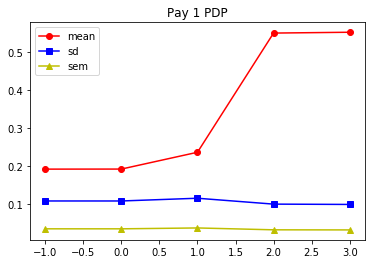

In [5]:
print("\nPD explanation:\n {}".format(str(pdp)))
pdp.explanations()[features[0]]['p_1'].transpose().plot(
    kind='line', style=['ro-', 'bs-', 'y^-'], title="Pay 1 PDP")
plt.show()

PD indicates that there **is** dependency of the prediction on `PAY_1` feature - if there is payment delay for 2 months or more.

Let's calculate at **limit balance** (numerical) feature:

In [6]:
%%capture
features = ['LIMIT_BAL']
exs = pdp.explain(features, X, predict_method=binomial_predict_method).explanations()


PD explanation:
 
'LIMIT_BAL':
 'p_0':
     20000.000000  73333.333333  126666.666667 180000.000000 233333.333333  \
mean      0.746057      0.769153      0.790744      0.809231      0.815782   
sd        0.180781      0.181809      0.188374      0.189186      0.189559   
sem      0.0571681      0.057493     0.0595692     0.0598259     0.0599437   
oor          False         False         False         False         False   

     286666.666667 340000.000000 393333.333333 446666.666667 500000.000000  
mean      0.819413      0.826423      0.829994      0.830299      0.831457  
sd        0.185784      0.184573      0.186002      0.186156      0.186406  
sem      0.0587499     0.0583671     0.0588191     0.0588678     0.0589469  
oor          False         False         False         False         False  
 'p_1':
     20000.000000  73333.333333  126666.666667 180000.000000 233333.333333  \
mean      0.253943      0.230847      0.209256      0.190769      0.184218   
sd        0.180781  

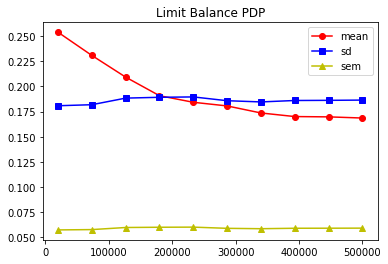

In [7]:
print("\nPD explanation:\n {}".format(str(pdp)))
pdp.explanations()['LIMIT_BAL']['p_1'].transpose().plot(
    kind='line', style=['ro-', 'bs-', 'y^-'], title="Limit Balance PDP")
plt.show()

PD indicates that there might be **data leakage** in case of `LIMIT_BAL` feature.

Calculate `PAY_1` and `LIMIT_BAL` to better understand their dependence:

In [8]:
%%capture
features = [('PAY_1', 'LIMIT_BAL')]
bins=[([0,1,2,4],[116000,164000,212000,260000])]
exs = PD("3D PD").explain(features, X, predict_method=binomial_predict_method, bins=bins).explanations()


PD explanation:
 {('PAY_1', 'LIMIT_BAL'): {'p_0':      (0, 116000) (0, 164000) (0, 212000) (0, 260000) (1, 116000) (1, 164000)  \
mean    0.822557    0.840673    0.848288    0.852314     0.78023    0.801944   
sd     0.0994473   0.0985449    0.097244   0.0963451    0.101527    0.103128   
sem     0.031448   0.0311626   0.0307512    0.030467   0.0321056   0.0326119   
oor        False       False       False       False       False       False   

     (1, 212000) (1, 260000) (2, 116000) (2, 164000) (2, 212000) (2, 260000)  \
mean    0.810488    0.814411    0.462782    0.490678    0.497509    0.503404   
sd      0.103317    0.102989   0.0856114   0.0877873   0.0869252    0.087159   
sem    0.0326716   0.0325681   0.0270727   0.0277608   0.0274882   0.0275621   
oor        False       False       False       False       False       False   

     (4, 116000) (4, 164000) (4, 212000) (4, 260000)  
mean    0.460368    0.488287     0.49512    0.501013  
sd     0.0850557   0.0872875   0.0864

Text(0.5,0,'prediction')

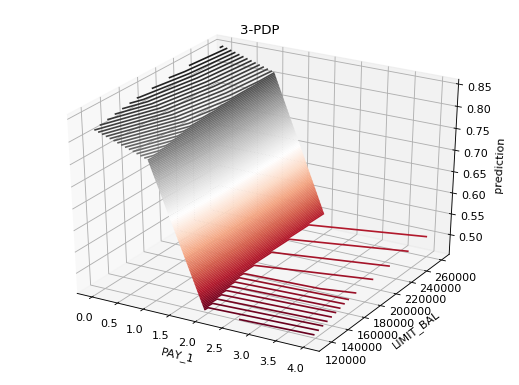

In [9]:
print("\nPD explanation:\n {}".format(str(exs)))

from mpl_toolkits import mplot3d

# data
x = bins[0][0]
y = bins[0][1]
df = exs[features[0]]['p_0']
z_dict = {}
for c in df.columns.values:
    if c[0] not in z_dict.keys():
        z_dict[c[0]] = []
    z_dict[c[0]].append(df.iloc[0][c])
z = pd.DataFrame(z_dict, columns=x, index=y)

# plot
fig = plt.figure(figsize=(8, 6), dpi=80)
ax = plt.axes(projection='3d')
ax.contour3D(x, y, z, 150,  cmap='RdGy')
ax.set_title('3-PDP');
ax.set_xlabel('PAY_1')
ax.set_ylabel('LIMIT_BAL')
ax.set_zlabel('prediction')

In order to determine interaction of features compute **Friedman's h-statistic**:

In [11]:
%%capture
h_statistic = HStatistic("Interaction of features").explain(
            ['PAY_1','PAY_2','LIMIT_BAL'],
            X,
            predict_method=regression_predict_method)
bins=[[0, 1, 2],[0, 1, 2],[164000.0, 212000.0, 260000.0]]


'('PAY_1', 'PAY_2')':
  'p_0':
    0.0011579186904548328
'('PAY_1', 'LIMIT_BAL')':
  'p_0':
    0.0035694774168201085
'('PAY_2', 'LIMIT_BAL')':
  'p_0':
    0.01072256237219022



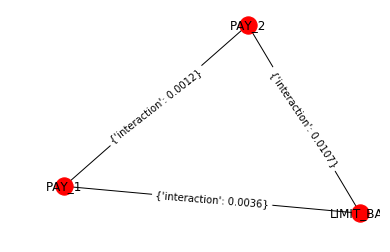

In [12]:
print(h_statistic)

import networkx as nx
G = nx.Graph()
exs = h_statistic.explanations()
for i in exs:
    G.add_edge(i[0], i[1], interaction=float("%0.4f"%exs[i]['p_0']))
pos = nx.spring_layout(G, weight='interaction')
nx.draw_networkx_edge_labels(G, pos)
nx.draw_networkx_labels(G, pos, with_labels=True)
nx.draw(G, pos)